<a href="https://colab.research.google.com/github/VrishankDesai/Ai-in-healthcare/blob/main/Heart_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

In [11]:
 # ─────────────────────────────────────────
# 1. UPLOAD AND LOAD DATASET
# ─────────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # upload processed_cleveland__1_.data

import io

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
           'restecg', 'thalach', 'exang', 'oldpeak',
           'slope', 'ca', 'thal', 'target']

df = pd.read_csv(io.BytesIO(uploaded[list(uploaded.keys())[0]]),
                 header=None, names=columns)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Saving processed.cleveland+(1).data to processed.cleveland+(1) (9).data
Shape: (303, 14)

First 5 rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  


In [12]:
# ─────────────────────────────────────────
# 2. HANDLE MISSING VALUES
# ─────────────────────────────────────────
# Dataset uses '?' for missing values
df.replace('?', np.nan, inplace=True)
df = df.astype(float)

print("\nMissing values per column:")
print(df.isnull().sum())

df.fillna(df.median(), inplace=True)

# Target: 0 = no disease, 1-4 = disease → convert to binary
df['target'] = (df['target'] > 0).astype(int)

print("\nTarget distribution:")
print(df['target'].value_counts())


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Target distribution:
target
0    164
1    139
Name: count, dtype: int64


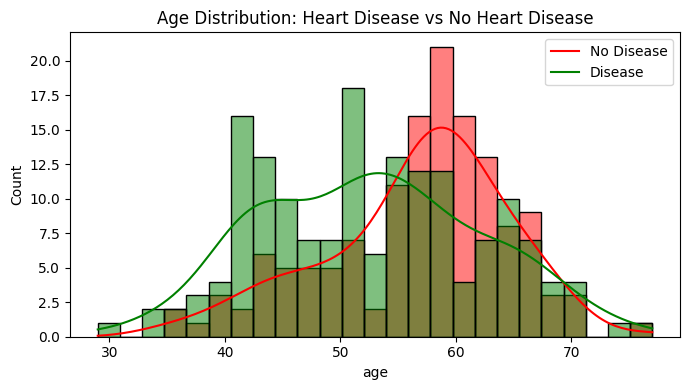

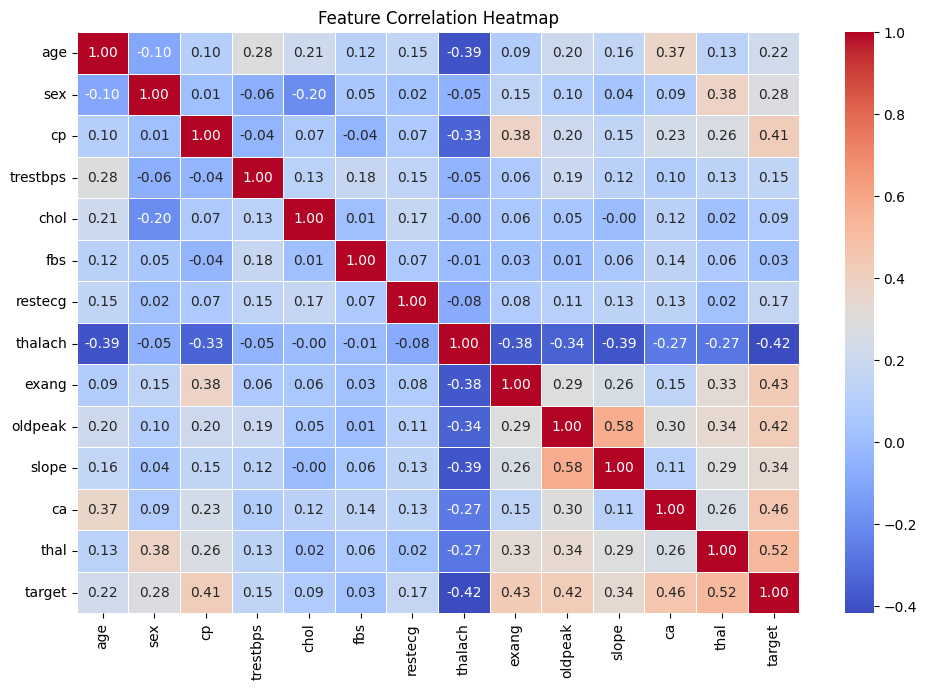

/tmp/ipykernel_2286/605938722.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='chol', palette=['lightgreen', 'salmon'])


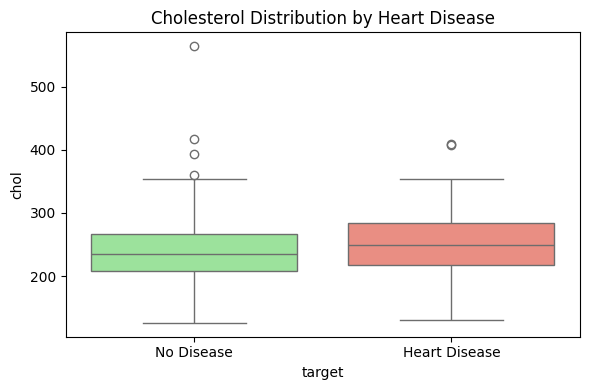

In [13]:
# ─────────────────────────────────────────
# 3. SEABORN PLOTS
# ─────────────────────────────────────────

# Plot 1: Age distribution by target
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='age', hue='target', kde=True,
             palette=['green', 'red'], bins=25)
plt.title("Age Distribution: Heart Disease vs No Heart Disease")
plt.legend(["No Disease", "Disease"])
plt.tight_layout()
plt.show()

# Plot 2: Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Plot 3: Cholesterol by target
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='target', y='chol', palette=['lightgreen', 'salmon'])
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])
plt.title("Cholesterol Distribution by Heart Disease")
plt.tight_layout()
plt.show()

In [14]:
# ─────────────────────────────────────────
# 4. PREPROCESSING
# ─────────────────────────────────────────
X = df.drop('target', axis=1).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]}, Test: {X_test.shape[0]}")


Train: 242, Test: 61


In [15]:
# ─────────────────────────────────────────
# 5. DEFINE ALL MODELS
# ─────────────────────────────────────────
models = {
    "Decision Tree"   : DecisionTreeClassifier(random_state=42),
    "SVM (RBF)"       : SVC(kernel='rbf', random_state=42),
    "Random Forest"   : RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN"             : KNeighborsClassifier(n_neighbors=5),
    "AdaBoost"        : AdaBoostClassifier(n_estimators=50, random_state=42),
    "MLP Classifier"  : MLPClassifier(hidden_layer_sizes=(64, 32),
                                      max_iter=500, random_state=42)
}

In [16]:
# ─────────────────────────────────────────
# 6. TRAIN AND EVALUATE ALL MODELS
# ─────────────────────────────────────────
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"\n── {name} ──")
    print(classification_report(y_test, y_pred,
                                target_names=['No Disease', 'Heart Disease']))


── Decision Tree ──
               precision    recall  f1-score   support

   No Disease       0.73      0.76      0.75        29
Heart Disease       0.77      0.75      0.76        32

     accuracy                           0.75        61
    macro avg       0.75      0.75      0.75        61
 weighted avg       0.75      0.75      0.75        61


── SVM (RBF) ──
               precision    recall  f1-score   support

   No Disease       0.87      0.93      0.90        29
Heart Disease       0.93      0.88      0.90        32

     accuracy                           0.90        61
    macro avg       0.90      0.90      0.90        61
 weighted avg       0.90      0.90      0.90        61


── Random Forest ──
               precision    recall  f1-score   support

   No Disease       0.84      0.90      0.87        29
Heart Disease       0.90      0.84      0.87        32

     accuracy                           0.87        61
    macro avg       0.87      0.87      0.87        6

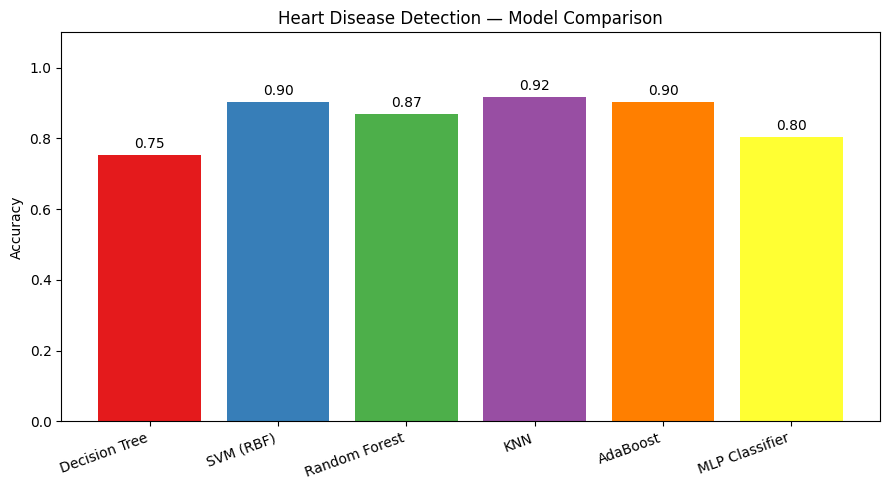

In [17]:
# ─────────────────────────────────────────
# 7. MODEL COMPARISON BAR CHART
# ─────────────────────────────────────────
plt.figure(figsize=(9, 5))
bars = plt.bar(results.keys(), results.values(),
               color=sns.color_palette("Set1", len(results)))
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Heart Disease Detection — Model Comparison")
plt.xticks(rotation=20, ha='right')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"{val:.2f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

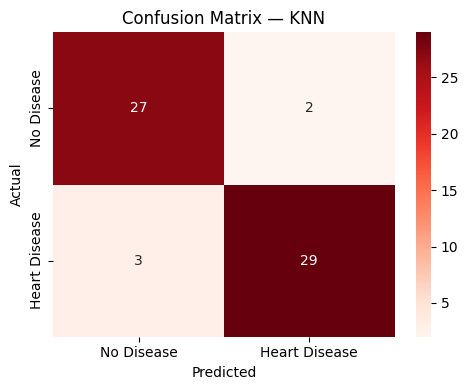


Best Model: KNN with accuracy 0.92


In [18]:
# ─────────────────────────────────────────
# 8. CONFUSION MATRIX FOR BEST MODEL
# ─────────────────────────────────────────
best_name  = max(results, key=results.get)
best_model = models[best_name]
y_best     = best_model.predict(X_test)
cm         = confusion_matrix(y_test, y_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"\nBest Model: {best_name} with accuracy {results[best_name]:.2f}")